In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn.metrics as metrics
from scipy.stats import binned_statistic


In [4]:
dat = pd.read_hdf("C:\data\Full_Model_Outputs.hdf5")
dat.head(1)
dat.describe()

,SYM_H_mean,AL_mean_2_delay,AL_mean_3_delay,AL_mean_4_delay,Vx_mean_6_delay,SYM_H_mean_7_delay,Vx_median_1_delay,AL_median_5_delay,Bz_median_7_delay,True Class,Prediction
0,-12.541667,-164.916667,-118.954861,-73.027778,-474.010588,-17.434028,-429.150009,-132.0,-0.555,0,1


,SYM_H_mean,AL_mean_2_delay,AL_mean_3_delay,AL_mean_4_delay,Vx_mean_6_delay,SYM_H_mean_7_delay,Vx_median_1_delay,AL_median_5_delay,Bz_median_7_delay,True Class,Prediction
count,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000
mean,-7.365012,-93.624921,-93.546570,-93.521626,-414.608700,-7.249352,-414.055726,-64.580537,-0.037627,0.393289,0.425503
std,10.737611,82.920705,82.955128,82.963159,83.592165,10.720416,85.054584,76.598193,1.003098,0.488808,0.494751
min,-73.020833,-551.947917,-551.947917,-551.947917,-720.038715,-73.020833,-720.500000,-523.000000,-9.360000,0.000000,0.000000
25%,-12.256944,-121.802083,-121.802083,-121.802083,-458.496355,-12.024306,-458.799988,-78.500000,-0.510000,0.000000,0.000000
50%,-5.805556,-64.090278,-64.034722,-63.743056,-392.723785,-5.607639,-391.500000,-33.000000,-0.030000,0.000000,0.000000
75%,-0.118056,-37.784722,-37.729167,-37.729167,-351.656407,-0.041667,-349.799988,-21.000000,0.420000,1.000000,1.000000
max,17.406250,-9.510417,-9.510417,-9.510417,-269.185938,17.406250,-266.699997,-2.000000,5.595000,1.000000,1.000000


# Main Analysis

Define the number of k-folds we want to use to calculate the statistics for each bin and the fraction of data we want to use in each k-fold. 

Define the size of whiskers to use, the col of the DataFrame we'll use as the x-axis and the range and number of bins for binning this data. 

Use a lambda function to define the metric we want to use. A lambda function is helpful cause we can quickly change which metric we want without modifying to much code. Note you can *hardcode* some aspects of the lambda function. For example

```python
met1 = lambda y_true, y_pred: metrics.accuracy_score(y_true, y_pred)
# or
met2 = lambda y_true, y_pred: metrics.accuracy_score(y_true, y_pred, normalize=False)
```

In [5]:
# k folds parameters
k_folds = 1000
k_size = 0.5

# whisker size
whisker = 1.5

# x data
x_col = 'SYM_H_mean'
x_ran = [-75,25]
x_sz = 25
x_bins = (x_ran[1]-x_ran[0])/x_sz

# use accuracy as the metric here
met = lambda y_true, y_pred: metrics.accuracy_score(y_true, y_pred)

In [6]:
# use bin statistic to determine which
# bin each value of DataFrame is in

# x_bnum - Indices of the bins (corresponding to bin_edges) 
# in which each value of x belongs. Same length as values. 
# A binnumber of i means the corresponding value is between (bin_edges[i-1], bin_edges[i]).

x_stat, x_edges, x_bnum = binned_statistic(dat[x_col],dat[x_col], bins=x_bins,range=x_ran)

x_cen = (x_edges[0:-1]+[x_edges[1:]])/2.
x_cen = x_cen.squeeze()
x_wid = x_edges[1]-x_edges[0]

In [10]:
# loop through the bins
# for each bin randombly sample values
# from the DataFrame which are in that bin
# and calculate the metric on that sample

# do this k-folds times
# from this calculate the values for a box plot

box_stats = [ ]

for i in np.arange(x_bins, dtype=int):
    gd = x_bnum == i+1
    val = np.array([ 
        met(dat.loc[gd,'True Class'].sample(frac=k_size, random_state=x),
            dat.loc[gd,'Prediction'].sample(frac=k_size,random_state=x)) 
            for x in np.arange(k_folds) 
            ])
    lq = np.nanpercentile(val,25)
    uq = np.nanpercentile(val,75)

    bval = {
                "mean":  np.nanmean(val),  # not required
                "med": np.nanmedian(val),
                "q1": lq,
                "q3": uq,
                "whislo": lq - whisker*(uq-lq),  # required
                "whishi": uq + whisker*(uq-lq),  # required
                "fliers": []  # required if showfliers=True
                }
    
    box_stats.append(bval)


Text(0, 0.5, 'Accuracy')

Text(0.5, 0, 'SYM_H_mean')

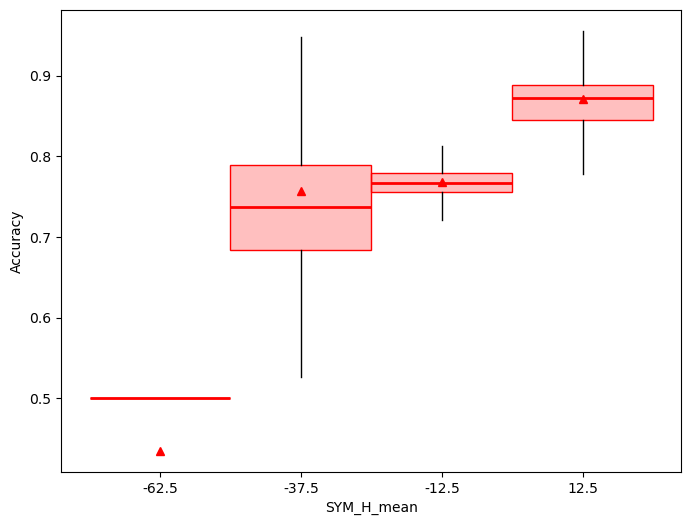

In [11]:
# plot the data
showmean=True
fig, ax = plt.subplots(1, figsize=(8,6))

y_val = box_stats # a list of dictionaries for each box/whisker instance
x_val = x_cen # the center of each x bin
x_width = x_wid # the width of each x bin

# lets define some colors, alpha values (transparencies) and other properties to
# make the plot pretty 

cc = [1,0,0] # red box plot
bx_a = 0.25 # transparency level (alpha) for box
ln_a = 1.0 # transparency level for lines
ln_w = 2.0 # line width

b1 = ax.bxp(y_val, positions=x_val, widths=x_width, 
                  patch_artist=True, showmeans=showmean, 
                  shownotches=False, showcaps=False, 
                  boxprops={'ec':cc+[ln_a], 'fc':cc+[bx_a]}, # artist properties for boxes
                  medianprops={'c':cc, 'lw':ln_w}, # artist properties for medians
                  meanprops={'mec':cc, 'mfc':cc}) # artist propoerties for means


ax.set_ylabel('Accuracy')
ax.set_xlabel(x_col)